In [1]:
import pandas as pd
from keras.optimizers import Adam
from keras.models import Sequential
from keras.losses import BinaryFocalCrossentropy
from keras.metrics import BinaryAccuracy, Precision, Recall, F1Score
from keras.layers import BatchNormalization, Dense, Dropout, InputLayer
from keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split

In [2]:
SEED = 42
INITIAL_LR = 0.01
FINAL_LR = 0.0001
BATCH_SIZE = 64
MODEL_DIR = 'C:\\Users\\meerh\\OneDrive\\Documentos\\Projetos\\esp32-fall-detection\\models'

In [3]:
df = pd.read_csv('C:\\Users\\meerh\\OneDrive\\Documentos\\Projetos\\esp32-fall-detection\\data\\processed\\acc_gyr.csv')
df.shape

(96800, 7)

In [4]:
df.head()

,xAcc,yAcc,zAcc,xGyro,yGyro,zGyro,label
0,6.99,-0.57,-7.28,-2.75,-3.23,2.62,1
1,6.51,-0.75,-6.93,-0.67,-6.35,4.64,1
2,6.22,-0.63,-6.73,0.79,-5.49,3.85,1
3,6.34,-0.62,-6.80,1.59,-2.26,0.67,1
4,6.49,-0.39,-6.60,0.67,-0.24,-1.10,1


In [5]:
df['label'].value_counts()

label
0    68800
1    28000
Name: count, dtype: int64

# Treino, Teste e Validação

In [6]:
X = df.drop('label', axis=1)
y = df['label']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_test, y_test, test_size=0.5, random_state=SEED, stratify=y_test)

X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape

((67760, 6), (67760,), (14520, 6), (14520,), (14520, 6), (14520,))

# Arquiteura da Rede Neural

In [8]:
model = Sequential([
    InputLayer(shape=(X_train.shape[1],)),
    Dense(1024, activation='relu'),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.15),
    
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.15),

    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.15),

    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    BatchNormalization(),
    Dropout(0.15),

    Dense(1, activation='sigmoid'),
])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1024)           │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8)              │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 709,921 (2.71 MB)

 Trainable params: 708,561 (2.70 MB)

 Non-trainable params: 1,360 (5.31 KB)

In [10]:
optimizer = Adam(learning_rate=INITIAL_LR)
loss_function = BinaryFocalCrossentropy(alpha=1, gamma=5)
metrics=[BinaryAccuracy(name='accuracy'), Precision(), Recall(), F1Score()]

In [11]:
model.compile(optimizer=optimizer, loss=loss_function, metrics=metrics)

# Treinamento do Modelo

In [12]:
callbacks = [
    EarlyStopping(monitor='val_recall', patience=20, restore_best_weights=True, mode='max'),
    ModelCheckpoint(f'{MODEL_DIR}/best_model_exp3.keras', monitor='val_recall', save_best_only=True, verbose=1, mode='max'),
    ReduceLROnPlateau(monitor='val_recall', factor=0.5, patience=4, min_lr=FINAL_LR, verbose=1, mode='max')
]

In [13]:
import numpy as np
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
weights = dict(enumerate(weights))
weights

{0: np.float64(0.7034883720930233), 1: np.float64(1.7285714285714286)}

In [14]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    class_weight=weights
)

Epoch 1/100


1057/1059 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6716 - f1_score: 0.4489 - loss: 0.0359 - precision: 0.4600 - recall: 0.5882
Epoch 1: val_recall improved from None to 0.56976, saving model to C:\Users\meerh\OneDrive\Documentos\Projetos\esp32-fall-detection\models/best_model_exp3.keras

Epoch 1: finished saving model to C:\Users\meerh\OneDrive\Documentos\Projetos\esp32-fall-detection\models/best_model_exp3.keras
1059/1059 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.7464 - f1_score: 0.4487 - loss: 0.0209 - precision: 0.5559 - recall: 0.6133 - val_accuracy: 0.8467 - val_f1_score: 0.4487 - val_loss: 0.0148 - val_precision: 0.8510 - val_recall: 0.5698 - learning_rate: 0.0100
Epoch 2/100
1056/1059 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8164 - f1_score: 0.4461 - loss: 0.0157 - precision: 0.7014 - recall: 0.6291
Epoch 2: val_recall improved from 0.56976 to 0.65333, saving model to C:\Users\meerh\OneDrive\Documentos\Projetos\esp32-fall-detection\models/best_model_exp3.ker

In [15]:
import matplotlib.pyplot as plt

def plot_recall(history):
    recall = history.history['recall']
    val_recall = history.history['val_recall']
    
    # Define o eixo X (número de épocas)
    epochs = range(1, len(recall) + 1)

    # Configura o tamanho da figura para melhor visualização
    plt.figure(figsize=(10, 6))

    # Plota as linhas de treinamento e validação
    plt.plot(epochs, recall, 'b-', label='Treinamento (Recall)', linewidth=2)
    plt.plot(epochs, val_recall, 'r--', label='Validação (Val_Recall)', linewidth=2)

    # Personaliza títulos e rótulos
    plt.title('Desempenho do Modelo: Recall por Época', fontsize=16, pad=15)
    plt.xlabel('Épocas', fontsize=14)
    plt.ylabel('Recall', fontsize=14)

    # Adiciona uma grade de fundo para facilitar a leitura dos valores
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Adiciona a legenda no canto inferior direito
    plt.legend(loc='lower right', fontsize=12)

    # Ajusta o layout e exibe o gráfico
    plt.tight_layout()
    plt.show()

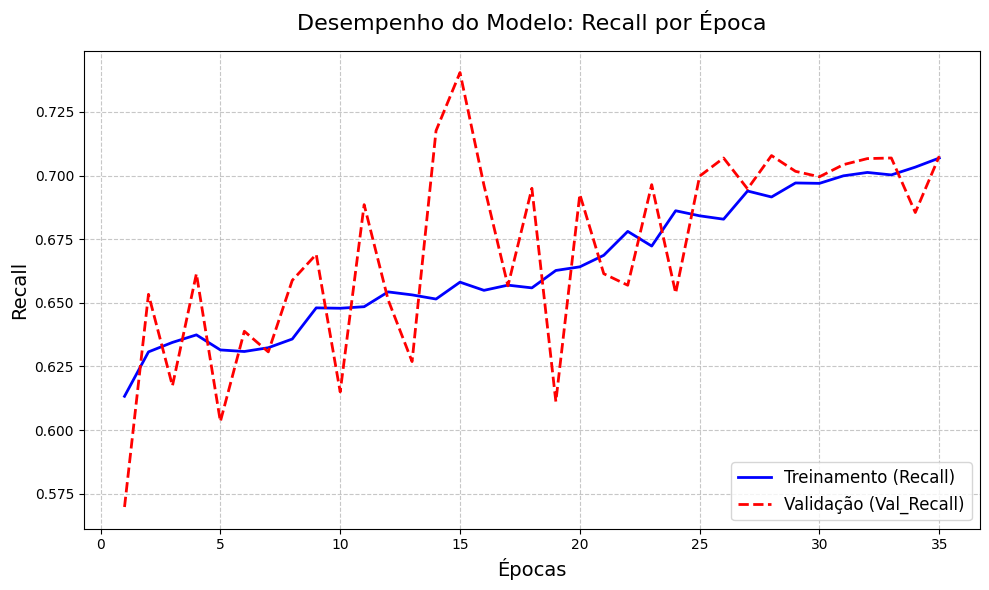

In [16]:
plot_recall(history)